# 📊 Exploratory Data Analysis (EDA)

## 📋 Notebook Overview
This notebook provides a comprehensive exploratory data analysis of the obesity prediction dataset. It serves as the first step in our machine learning pipeline to understand the data structure, distributions, relationships, and patterns.

### 🎯 Objectives:
- Load and examine the raw dataset
- Perform descriptive statistical analysis
- Visualize feature distributions
- Analyze correlations between numerical features
- Calculate Cramér's V for categorical vs target relationships
- Identify data quality issues and patterns
- Generate comprehensive EDA report

### 📁 Input/Output:
- **Input**: `../data/Obesity_data.csv`
- **Output**: EDA plots and analysis saved to `../results/eda/`

### 🔗 Workflow Position:
- **Current**: `00_EDA.ipynb` → Exploratory Data Analysis
- **Next**: `01_Preprocessing.ipynb` → Data Preprocessing

---

## 📚 Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency

# Utility libraries
from pathlib import Path
import warnings
import json

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Load Dataset

In [2]:
# Create results directory for EDA outputs
eda_results_dir = Path('../results/eda')
eda_results_dir.mkdir(parents=True, exist_ok=True)

# Load the dataset
data_path = Path('../data/loaded_data.csv')

if data_path.exists():
    df = pd.read_csv(data_path)
    print(f'✅ Dataset loaded successfully!')
    print(f'📊 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
else:
    raise FileNotFoundError(f'Dataset not found at {data_path}')

# Display first few rows
print('\n📋 First 5 rows of the dataset:')
display(df.head())

✅ Dataset loaded successfully!
📊 Dataset shape: 20,758 rows × 18 columns

📋 First 5 rows of the dataset:


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


## 🔍 Dataset Overview

In [3]:
# Basic dataset information
print('📊 DATASET OVERVIEW')
print('=' * 80)

print(f'📏 Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print('\n🏷️ Column Information:')
info_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})

display(info_df)

# Identify feature types
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f'\n📈 Numerical features ({len(numerical_features)}): {numerical_features}')
print(f'🏷️ Categorical features ({len(categorical_features)}): {categorical_features}')

# Check for duplicates
duplicates = df.duplicated().sum()
print(f'\n🔍 Duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)')

📊 DATASET OVERVIEW
📏 Dimensions: 20,758 rows × 18 columns
💾 Memory usage: 11.46 MB

🏷️ Column Information:


,Column,Data Type,Non-Null Count,Null Count,Null %,Unique Values
id,id,int64,20758,0,0.0,20758
Gender,Gender,object,20758,0,0.0,2
Age,Age,float64,20758,0,0.0,1703
Height,Height,float64,20758,0,0.0,1833
Weight,Weight,float64,20758,0,0.0,1979
family_history_with_overweight,family_history_with_overweight,object,20758,0,0.0,2
FAVC,FAVC,object,20758,0,0.0,2
FCVC,FCVC,float64,20758,0,0.0,934
NCP,NCP,float64,20758,0,0.0,689
CAEC,CAEC,object,20758,0,0.0,4



📈 Numerical features (9): ['id', 'Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
🏷️ Categorical features (9): ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

🔍 Duplicate rows: 0 (0.00%)


## 🎯 Target Variable Analysis

🎯 TARGET VARIABLE ANALYSIS
Target Variable: NObeyesdad
Number of classes: 7
Total samples: 20,758

📊 Class Distribution:


,Class,Count,Percentage
0,Obesity_Type_III,4046,19.49
1,Obesity_Type_II,3248,15.65
2,Normal_Weight,3082,14.85
3,Obesity_Type_I,2910,14.02
4,Insufficient_Weight,2523,12.15
5,Overweight_Level_II,2522,12.15
6,Overweight_Level_I,2427,11.69


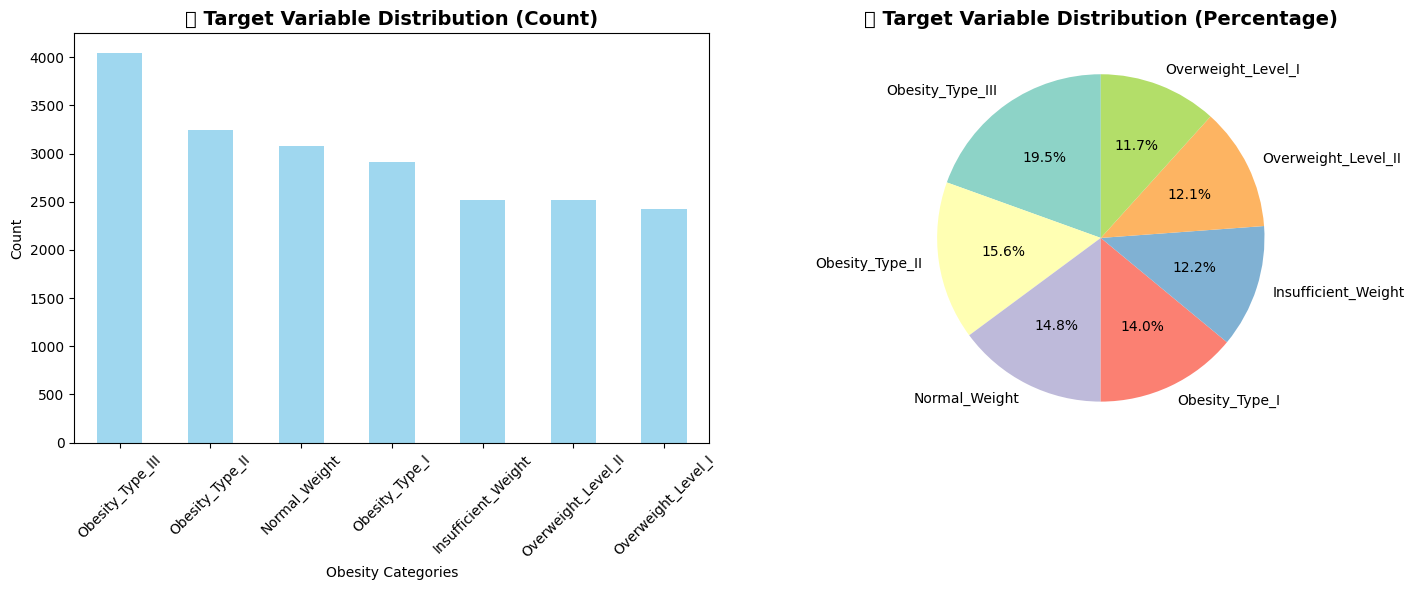

In [4]:
# Identify target variable (assuming it's 'NObeyesdad' based on obesity prediction)
target_col = 'NObeyesdad'

if target_col in df.columns:
    print('🎯 TARGET VARIABLE ANALYSIS')
    print('=' * 80)
    
    target_counts = df[target_col].value_counts()
    target_props = df[target_col].value_counts(normalize=True) * 100
    
    print(f'Target Variable: {target_col}')
    print(f'Number of classes: {len(target_counts)}')
    print(f'Total samples: {len(df):,}')
    
    print('\n📊 Class Distribution:')
    target_summary = pd.DataFrame({
        'Class': target_counts.index,
        'Count': target_counts.values,
        'Percentage': target_props.values.round(2)
    })
    display(target_summary)
    
    # Visualize target distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar plot
    target_counts.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.8)
    ax1.set_title('🎯 Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Obesity Categories')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    
    # Pie chart
    ax2.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=plt.cm.Set3.colors)
    ax2.set_title('🎯 Target Variable Distribution (Percentage)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(eda_results_dir / 'target_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Remove target from categorical features for further analysis
    if target_col in categorical_features:
        categorical_features.remove(target_col)
        
else:
    print('⚠️ Target variable not found in dataset')

## 📈 Numerical Features Analysis

📈 NUMERICAL FEATURES ANALYSIS
📊 Descriptive Statistics:


,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


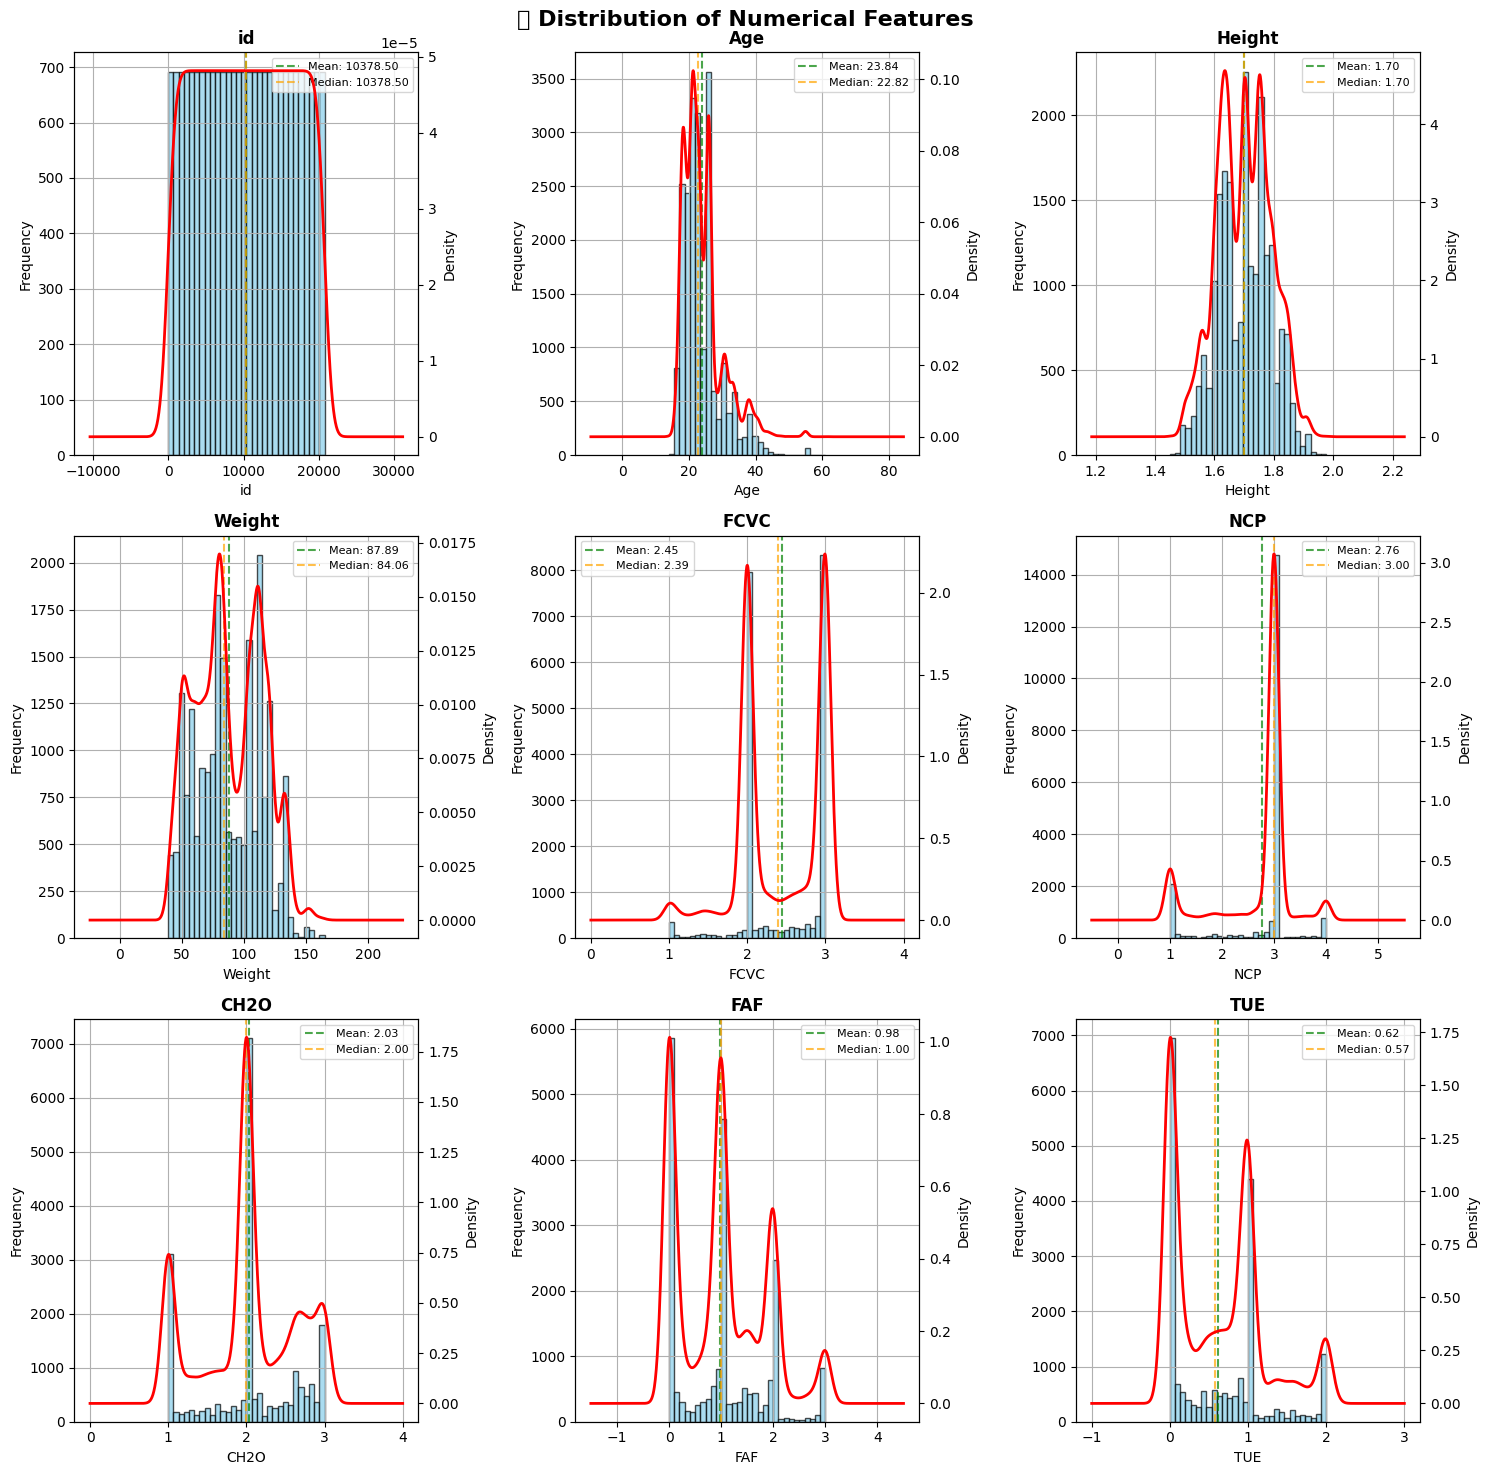

In [5]:
if len(numerical_features) > 0:
    print('📈 NUMERICAL FEATURES ANALYSIS')
    print('=' * 80)
    
    # Descriptive statistics
    print('📊 Descriptive Statistics:')
    desc_stats = df[numerical_features].describe()
    display(desc_stats)
    
    # Distribution plots
    n_features = len(numerical_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    fig.suptitle('📊 Distribution of Numerical Features', fontsize=16, fontweight='bold')
    
    if n_rows == 1:
        axes = [axes] if n_features == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, feature in enumerate(numerical_features):
        ax = axes[i]
        
        # Create histogram with KDE
        df[feature].hist(bins=30, alpha=0.7, ax=ax, color='skyblue', edgecolor='black')
        ax2 = ax.twinx()
        df[feature].plot(kind='kde', ax=ax2, color='red', linewidth=2)
        
        ax.set_title(f'{feature}', fontweight='bold')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')
        ax2.set_ylabel('Density')
        
        # Add statistics text
        mean_val = df[feature].mean()
        median_val = df[feature].median()
        ax.axvline(mean_val, color='green', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='orange', linestyle='--', alpha=0.7, label=f'Median: {median_val:.2f}')
        ax.legend(fontsize=8)
    
    # Hide empty subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(eda_results_dir / 'numerical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('📊 No numerical features found for analysis')

## 🔗 Correlation Analysis (Numerical Features)

🔗 CORRELATION ANALYSIS


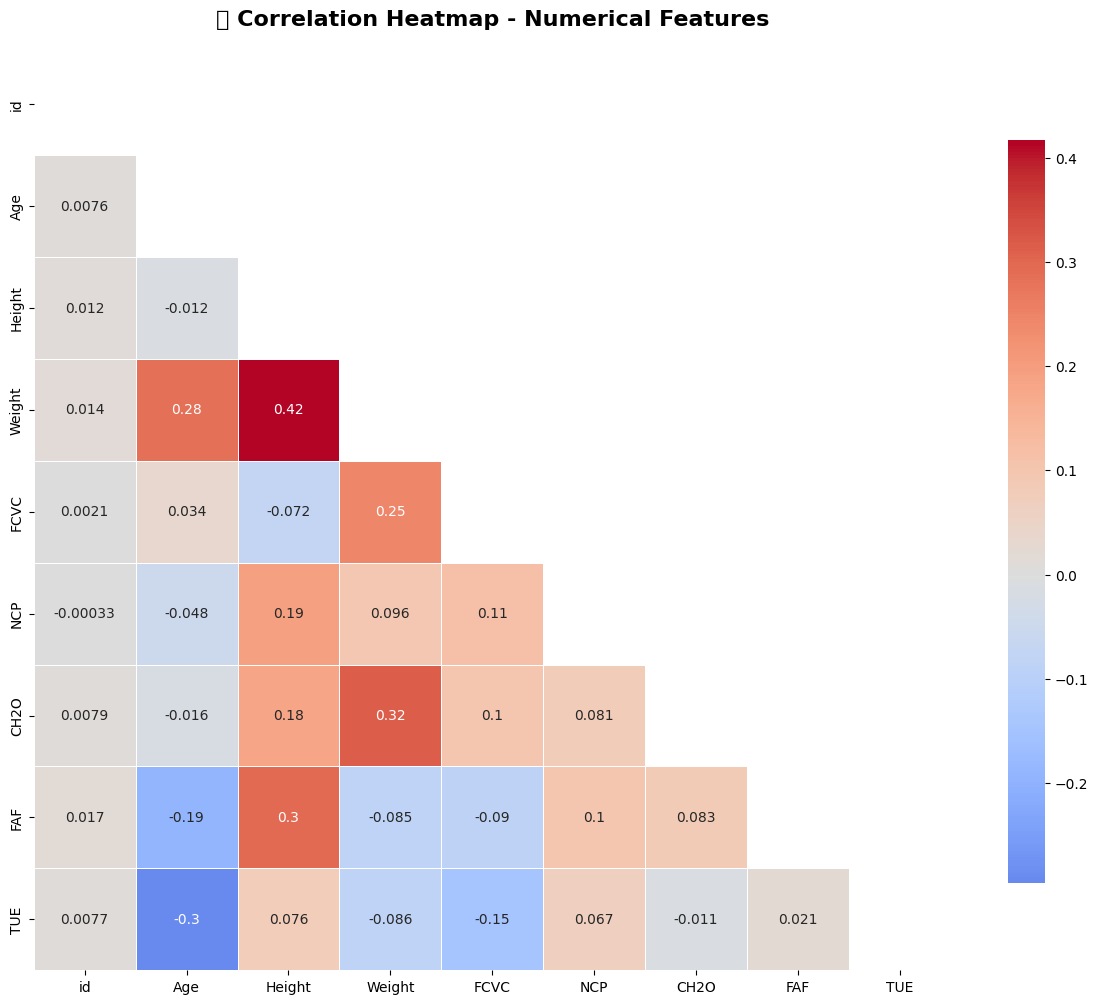


🔍 Highly Correlated Feature Pairs (|correlation| > 0.7):
✅ No highly correlated feature pairs found.


In [6]:
if len(numerical_features) > 1:
    print('🔗 CORRELATION ANALYSIS')
    print('=' * 80)
    
    # Calculate correlation matrix
    correlation_matrix = df[numerical_features].corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    
    plt.title('🔗 Correlation Heatmap - Numerical Features', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(eda_results_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Find highly correlated pairs
    print('\n🔍 Highly Correlated Feature Pairs (|correlation| > 0.7):')
    high_corr_pairs = []
    
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                high_corr_pairs.append({
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Correlation': corr_val
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs)
        display(high_corr_df)
    else:
        print('✅ No highly correlated feature pairs found.')
        
elif len(numerical_features) == 1:
    print(f'📊 Only one numerical feature found: {numerical_features[0]}')
else:
    print('📊 No numerical features found for correlation analysis')

## 🏷️ Categorical Features Analysis

🏷️ CATEGORICAL FEATURES ANALYSIS


,Feature,Unique Values,Most Frequent,Most Frequent Count,Most Frequent %
0,Gender,2,Female,10422,50.21
1,family_history_with_overweight,2,yes,17014,81.96
2,FAVC,2,yes,18982,91.44
3,CAEC,4,Sometimes,17529,84.44
4,SMOKE,2,no,20513,98.82
5,SCC,2,no,20071,96.69
6,CALC,3,Sometimes,15066,72.58
7,MTRANS,5,Public_Transportation,16687,80.39


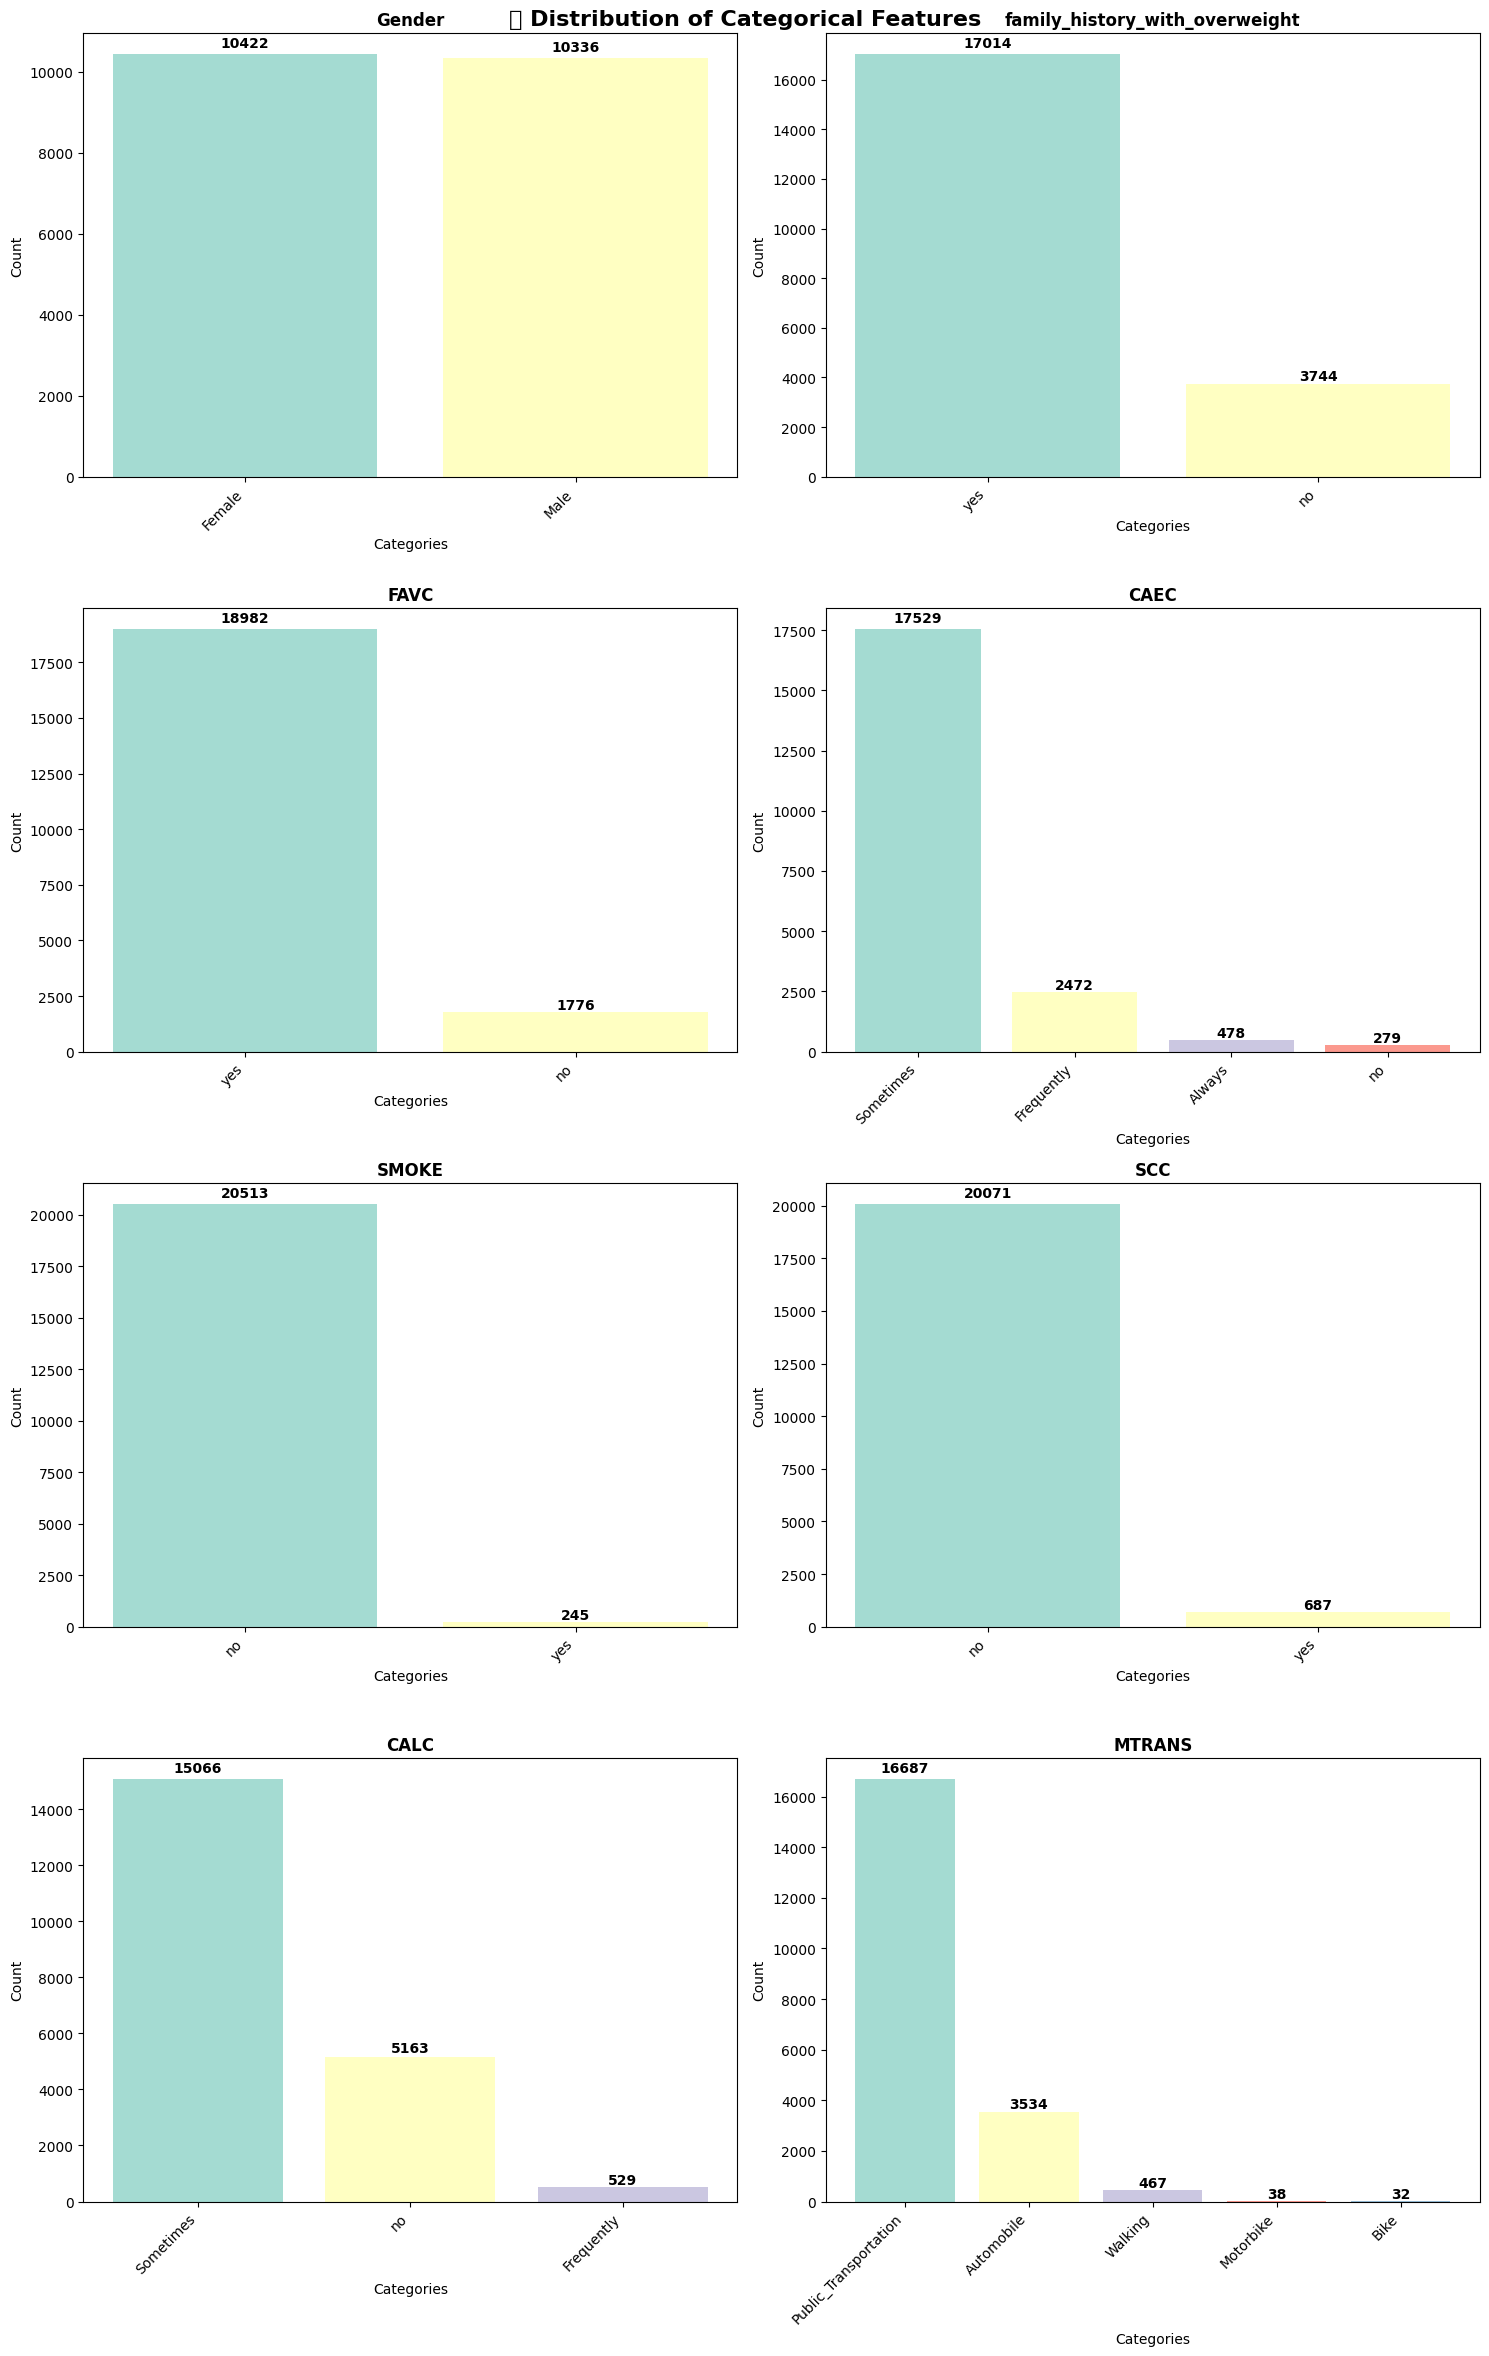

In [7]:
if len(categorical_features) > 0:
    print('🏷️ CATEGORICAL FEATURES ANALYSIS')
    print('=' * 80)
    
    # Analyze each categorical feature
    cat_summary = []
    
    for feature in categorical_features:
        unique_vals = df[feature].nunique()
        most_frequent = df[feature].mode()[0]
        most_frequent_count = df[feature].value_counts().iloc[0]
        most_frequent_pct = (most_frequent_count / len(df)) * 100
        
        cat_summary.append({
            'Feature': feature,
            'Unique Values': unique_vals,
            'Most Frequent': most_frequent,
            'Most Frequent Count': most_frequent_count,
            'Most Frequent %': round(most_frequent_pct, 2)
        })
    
    cat_summary_df = pd.DataFrame(cat_summary)
    display(cat_summary_df)
    
    # Visualize categorical features
    n_features = len(categorical_features)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6*n_rows))
    fig.suptitle('🏷️ Distribution of Categorical Features', fontsize=16, fontweight='bold')
    
    if n_rows == 1:
        axes = [axes] if n_features == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, feature in enumerate(categorical_features):
        ax = axes[i]
        value_counts = df[feature].value_counts()
        
        # Create bar plot
        bars = ax.bar(range(len(value_counts)), value_counts.values, 
                     color=plt.cm.Set3.colors[:len(value_counts)], alpha=0.8)
        
        ax.set_title(f'{feature}', fontweight='bold')
        ax.set_xlabel('Categories')
        ax.set_ylabel('Count')
        ax.set_xticks(range(len(value_counts)))
        ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
        
        # Add value labels on bars
        for bar, count in zip(bars, value_counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + count*0.01,
                   str(count), ha='center', va='bottom', fontweight='bold')
    
    # Hide empty subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(eda_results_dir / 'categorical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('🏷️ No categorical features found for analysis')

## 📊 Cramér's V Analysis (Categorical vs Target)

📊 CRAMÉR'S V ANALYSIS (Categorical Features vs Target)
🔍 Cramér's V Results (sorted by strength):


,Feature,Cramers_V,Strength
0,Gender,0.618786,Strong
1,family_history_with_overweight,0.556025,Strong
3,CAEC,0.332392,Strong
6,CALC,0.310457,Strong
2,FAVC,0.273056,Moderate
5,SCC,0.221545,Moderate
7,MTRANS,0.167355,Moderate
4,SMOKE,0.100656,Moderate


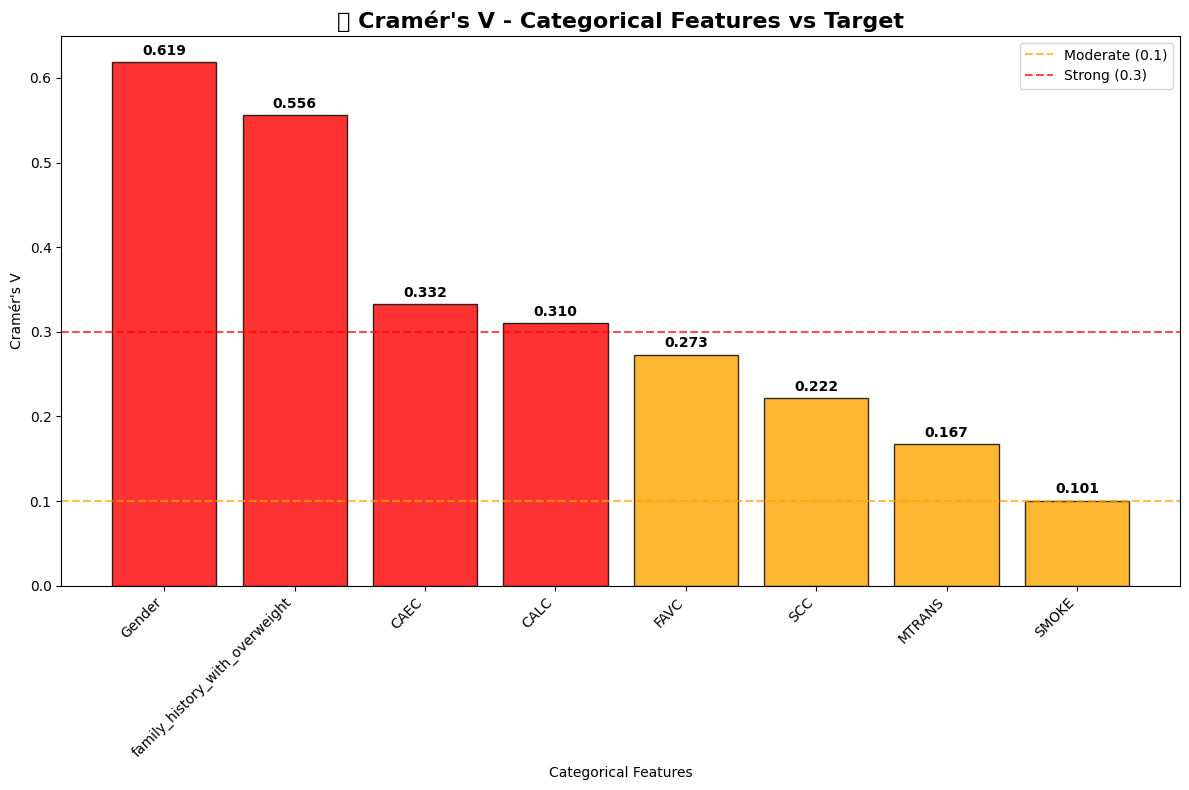

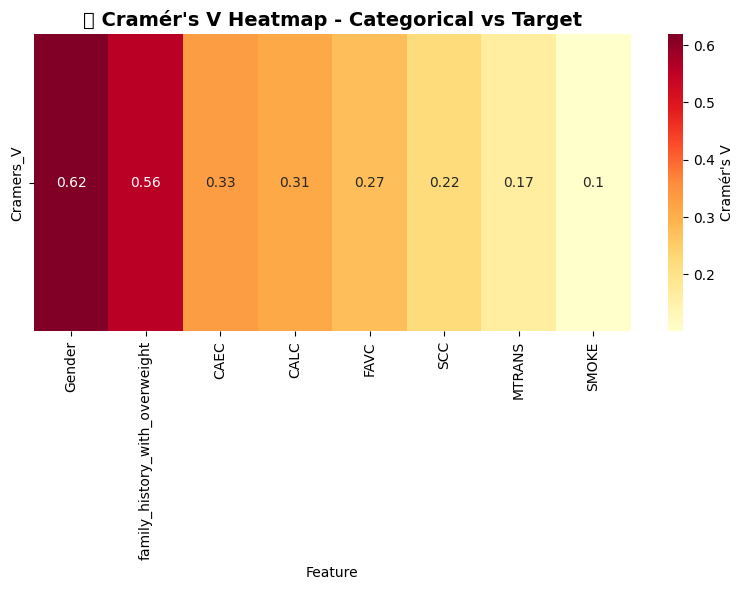

In [8]:
def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    Uses bias correction from Bergsma and Wicher, 2013.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

if target_col in df.columns and len(categorical_features) > 0:
    print('📊 CRAMÉR\'S V ANALYSIS (Categorical Features vs Target)')
    print('=' * 80)
    
    cramers_v_results = []
    
    for feature in categorical_features:
        try:
            cramers_val = cramers_v(df[feature], df[target_col])
            cramers_v_results.append({
                'Feature': feature,
                'Cramers_V': cramers_val,
                'Strength': 'Strong' if cramers_val > 0.3 else 'Moderate' if cramers_val > 0.1 else 'Weak'
            })
        except Exception as e:
            print(f'⚠️ Error calculating Cramér\'s V for {feature}: {e}')
            cramers_v_results.append({
                'Feature': feature,
                'Cramers_V': np.nan,
                'Strength': 'Error'
            })
    
    # Create results DataFrame
    cramers_df = pd.DataFrame(cramers_v_results).sort_values('Cramers_V', ascending=False)
    print('🔍 Cramér\'s V Results (sorted by strength):')
    display(cramers_df)
    
    # Visualize Cramér's V values
    plt.figure(figsize=(12, 8))
    
    # Filter out NaN values for plotting
    valid_results = cramers_df.dropna(subset=['Cramers_V'])
    
    if len(valid_results) > 0:
        colors = ['red' if x > 0.3 else 'orange' if x > 0.1 else 'lightblue' 
                 for x in valid_results['Cramers_V']]
        
        bars = plt.bar(range(len(valid_results)), valid_results['Cramers_V'], 
                      color=colors, alpha=0.8, edgecolor='black')
        
        plt.title('📊 Cramér\'s V - Categorical Features vs Target', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Categorical Features')
        plt.ylabel('Cramér\'s V')
        plt.xticks(range(len(valid_results)), valid_results['Feature'], rotation=45, ha='right')
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, valid_results['Cramers_V'])):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # Add horizontal lines for interpretation
        plt.axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='Moderate (0.1)')
        plt.axhline(y=0.3, color='red', linestyle='--', alpha=0.7, label='Strong (0.3)')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(eda_results_dir / 'cramers_v_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Create Cramér's V heatmap
        plt.figure(figsize=(8, 6))
        cramers_matrix = valid_results.set_index('Feature')[['Cramers_V']].T
        sns.heatmap(cramers_matrix, annot=True, cmap='YlOrRd', cbar_kws={'label': 'Cramér\'s V'})
        plt.title('🔥 Cramér\'s V Heatmap - Categorical vs Target', 
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(eda_results_dir / 'cramers_v_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
    
else:
    print('⚠️ Cannot perform Cramér\'s V analysis - target or categorical features not available')

## 📋 EDA Summary Report

In [9]:
# Generate comprehensive EDA summary
print('📋 EDA SUMMARY REPORT')
print('=' * 80)

# Dataset overview
print('🔍 Dataset Overview:')
print(f'   • Total samples: {len(df):,}')
print(f'   • Total features: {len(df.columns)}')
print(f'   • Numerical features: {len(numerical_features)}')
print(f'   • Categorical features: {len(categorical_features)}')
print(f'   • Missing values: {df.isnull().sum().sum():,}')
print(f'   • Duplicate rows: {df.duplicated().sum():,}')
print(f'   • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

# Target analysis
if target_col in df.columns:
    print('\n🎯 Target Variable:')
    print(f'   • Variable name: {target_col}')
    print(f'   • Number of classes: {df[target_col].nunique()}')
    print(f'   • Most frequent class: {df[target_col].mode()[0]}')
    print(f'   • Class balance: {"Balanced" if df[target_col].value_counts().std() < df[target_col].value_counts().mean() * 0.5 else "Imbalanced"}')

# Feature analysis summary
print('\n📊 Feature Analysis:')
if len(numerical_features) > 1:
    high_corr_count = len([1 for i in range(len(df[numerical_features].corr().columns)) 
                          for j in range(i+1, len(df[numerical_features].corr().columns)) 
                          if abs(df[numerical_features].corr().iloc[i, j]) > 0.7])
    print(f'   • Highly correlated numerical pairs: {high_corr_count}')

if 'cramers_df' in locals() and len(cramers_df.dropna()) > 0:
    strong_associations = len(cramers_df[cramers_df['Strength'] == 'Strong'])
    moderate_associations = len(cramers_df[cramers_df['Strength'] == 'Moderate'])
    print(f'   • Strong categorical-target associations (Cramér\'s V > 0.3): {strong_associations}')
    print(f'   • Moderate categorical-target associations (Cramér\'s V > 0.1): {moderate_associations}')

# Save EDA summary to file
eda_summary = {
    'dataset_shape': list(df.shape),
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'target_variable': target_col if target_col in df.columns else None,
    'missing_values': int(df.isnull().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum()),
    'target_classes': list(df[target_col].unique()) if target_col in df.columns else [],
    'cramers_v_results': cramers_v_results if 'cramers_v_results' in locals() else [],
    'analysis_timestamp': pd.Timestamp.now().isoformat()
}

with open(eda_results_dir / 'eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2, default=str)

print('\n✅ EDA Analysis Complete!')
print(f'📁 All plots and results saved to: {eda_results_dir}')
print(f'📄 Summary report saved as: {eda_results_dir}/eda_summary.json')

print('\n🔄 Next Step: Run 01_Preprocessing.ipynb for data preprocessing')

📋 EDA SUMMARY REPORT
🔍 Dataset Overview:
   • Total samples: 20,758
   • Total features: 18
   • Numerical features: 9
   • Categorical features: 8
   • Missing values: 0
   • Duplicate rows: 0
   • Memory usage: 11.46 MB

🎯 Target Variable:
   • Variable name: NObeyesdad
   • Number of classes: 7
   • Most frequent class: Obesity_Type_III
   • Class balance: Balanced

📊 Feature Analysis:
   • Highly correlated numerical pairs: 0
   • Strong categorical-target associations (Cramér's V > 0.3): 4
   • Moderate categorical-target associations (Cramér's V > 0.1): 4

✅ EDA Analysis Complete!
📁 All plots and results saved to: ..\results\eda
📄 Summary report saved as: ..\results\eda/eda_summary.json

🔄 Next Step: Run 01_Preprocessing.ipynb for data preprocessing
